<a href="https://colab.research.google.com/github/Navvvermanew/Demand-Forecasting/blob/main/Demand-Forecasting/Notebook/Project_one.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files

In [3]:
uploaded = files.upload()

Saving train.csv to train.csv


In [4]:
import pandas as pd
df = pd.read_csv("train.csv")
print(df.shape)
df.sample(5)

(3000888, 6)


,id,date,store_nbr,family,sales,onpromotion
2044449,2044449,2016-02-25,23,AUTOMOTIVE,0.0,0
1526702,1526702,2015-05-09,45,MAGAZINES,13.0,0
2746062,2746062,2017-03-26,1,AUTOMOTIVE,5.0,0
318736,318736,2013-06-28,51,"LIQUOR,WINE,BEER",234.0,0
600580,600580,2013-12-04,10,GROCERY II,1.0,0


In [5]:
# Basic information about the dataset

print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDate range:")
print(df["date"].min(), "to", df["date"].max())

print("\nNumber of unique stores:", df["store_nbr"].nunique())
print("Number of product families:", df["family"].nunique())

print("\nProduct families:")
print(df["family"].unique())

Shape: (3000888, 6)

Column names:
['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']

Data types:
id               int64
date            object
store_nbr        int64
family          object
sales          float64
onpromotion      int64
dtype: object

Missing values:
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

Date range:
2013-01-01 to 2017-08-15

Number of unique stores: 54
Number of product families: 33

Product families:
['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LAWN AND GARDEN' 'LINGERIE'
 'LIQUOR,WINE,BEER' 'MAGAZINES' 'MEATS' 'PERSONAL CARE' 'PET SUPPLIES'
 'PLAYERS AND ELECTRONICS' 'POULTRY' 'PREPARED FOODS' 'PRODUCE'
 'SCHOOL AND OFFICE SUPPLIES' 'SEAFOOD']


In [6]:
# Step 3: Check the number of observations for each time series

series_info = (
    df.groupby(["store_nbr", "family"])
      .agg(
          observations=("sales", "count"),
          start_date=("date", "min"),
          end_date=("date", "max")
      )
      .reset_index()
)

print("Total number of series:", len(series_info))

print("\nObservation count statistics:")
print(series_info["observations"].describe())

print("\nSeries with fewer than 1,000 observations:")
print((series_info["observations"] < 1000).sum())

print("\nFirst 10 series:")
display(series_info.head(10))

Total number of series: 1782

Observation count statistics:
count    1782.0
mean     1684.0
std         0.0
min      1684.0
25%      1684.0
50%      1684.0
75%      1684.0
max      1684.0
Name: observations, dtype: float64

Series with fewer than 1,000 observations:
0

First 10 series:


,store_nbr,family,observations,start_date,end_date
0,1,AUTOMOTIVE,1684,2013-01-01,2017-08-15
1,1,BABY CARE,1684,2013-01-01,2017-08-15
2,1,BEAUTY,1684,2013-01-01,2017-08-15
3,1,BEVERAGES,1684,2013-01-01,2017-08-15
4,1,BOOKS,1684,2013-01-01,2017-08-15
5,1,BREAD/BAKERY,1684,2013-01-01,2017-08-15
6,1,CELEBRATION,1684,2013-01-01,2017-08-15
7,1,CLEANING,1684,2013-01-01,2017-08-15
8,1,DAIRY,1684,2013-01-01,2017-08-15
9,1,DELI,1684,2013-01-01,2017-08-15


In [7]:
# Step 4: Convert daily data into monthly sales

# Convert date from object/string to datetime
df["date"] = pd.to_datetime(df["date"])

# Keep the 38-month period: Jan 2014 to Feb 2017
df_monthly_raw = df[
    (df["date"] >= "2014-01-01") &
    (df["date"] <= "2017-02-28")
].copy()

# Create a monthly period
df_monthly_raw["month"] = df_monthly_raw["date"].dt.to_period("M")

# Aggregate daily sales to monthly sales
monthly_sales = (
    df_monthly_raw
    .groupby(["store_nbr", "family", "month"])["sales"]
    .sum()
    .reset_index()
)

print("Monthly dataset shape:", monthly_sales.shape)

print("\nNumber of unique series:",
      monthly_sales.groupby(["store_nbr", "family"]).ngroups)

print("\nNumber of months:",
      monthly_sales["month"].nunique())

print("\nMonth range:",
      monthly_sales["month"].min(),
      "to",
      monthly_sales["month"].max())

display(monthly_sales.head(10))

Monthly dataset shape: (67716, 4)

Number of unique series: 1782

Number of months: 38

Month range: 2014-01 to 2017-02


,store_nbr,family,month,sales
0,1,AUTOMOTIVE,2014-01,75.0
1,1,AUTOMOTIVE,2014-02,85.0
2,1,AUTOMOTIVE,2014-03,97.0
3,1,AUTOMOTIVE,2014-04,76.0
4,1,AUTOMOTIVE,2014-05,63.0
5,1,AUTOMOTIVE,2014-06,65.0
6,1,AUTOMOTIVE,2014-07,108.0
7,1,AUTOMOTIVE,2014-08,68.0
8,1,AUTOMOTIVE,2014-09,101.0
9,1,AUTOMOTIVE,2014-10,93.0


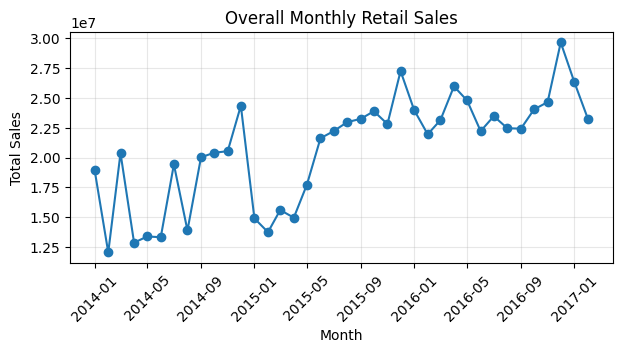

In [8]:
import matplotlib.pyplot as plt

# Aggregate sales across all stores and product families
overall_monthly = (
    monthly_sales
    .groupby("month")["sales"]
    .sum()
    .reset_index()
)

# Convert Period to timestamp for plotting
overall_monthly["month"] = overall_monthly["month"].dt.to_timestamp()

plt.figure(figsize=(7, 3))

plt.plot(
    overall_monthly["month"],
    overall_monthly["sales"],
    marker="o"
)

plt.title("Overall Monthly Retail Sales")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.show()

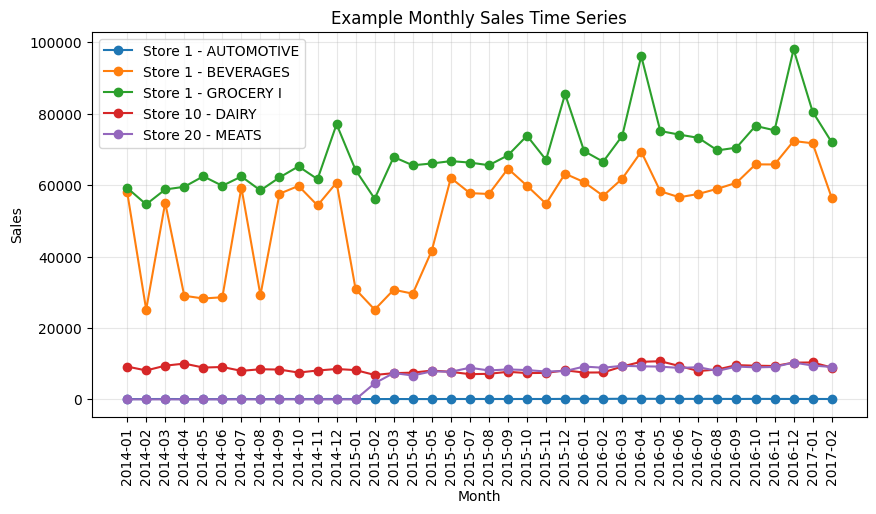

In [9]:
# Select 5 example series
example_series = [
    (1, "AUTOMOTIVE"),
    (1, "BEVERAGES"),
    (1, "GROCERY I"),
    (10, "DAIRY"),
    (20, "MEATS")
]

plt.figure(figsize=(10, 5))

for store, family in example_series:

    temp = monthly_sales[
        (monthly_sales["store_nbr"] == store) &
        (monthly_sales["family"] == family)
    ].copy()

    plt.plot(
        temp["month"].astype(str),
        temp["sales"],
        marker="o",
        label=f"Store {store} - {family}"
    )

plt.title("Example Monthly Sales Time Series")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

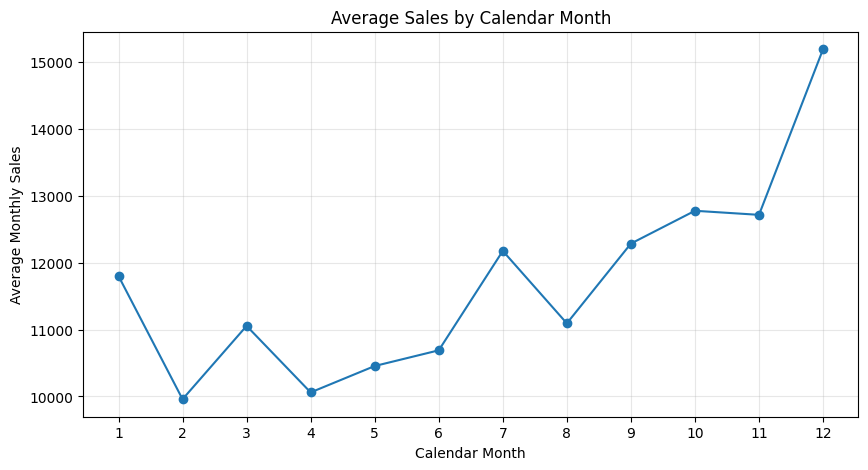

In [10]:
# Extract calendar month
seasonality = monthly_sales.copy()

seasonality["calendar_month"] = (
    seasonality["month"].dt.month
)

# Average sales across all series for each calendar month
monthly_seasonality = (
    seasonality
    .groupby("calendar_month")["sales"]
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_seasonality.index,
    monthly_seasonality.values,
    marker="o"
)

plt.title("Average Sales by Calendar Month")
plt.xlabel("Calendar Month")
plt.ylabel("Average Monthly Sales")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)

plt.show()

In [11]:
# Calculate coefficient of variation across calendar months
seasonality_mean = monthly_seasonality.mean()
seasonality_std = monthly_seasonality.std()

seasonality_cv = seasonality_std / seasonality_mean

print("Average monthly sales:", round(seasonality_mean, 2))
print("Standard deviation:", round(seasonality_std, 2))
print("Seasonality coefficient of variation:", round(seasonality_cv, 4))

Average monthly sales: 11688.08
Standard deviation: 1478.95
Seasonality coefficient of variation: 0.1265


In [12]:
# Step 6: Create the final monthly dataset

# Make sure date is datetime
df["date"] = pd.to_datetime(df["date"])

# Keep our 38-month modelling period
df_model = df[
    (df["date"] >= "2014-01-01") &
    (df["date"] <= "2017-02-28")
].copy()

# Create monthly period
df_model["month"] = df_model["date"].dt.to_period("M")

# Aggregate daily data to monthly level
monthly_data = (
    df_model
    .groupby(["store_nbr", "family", "month"])
    .agg(
        sales=("sales", "sum"),
        onpromotion=("onpromotion", "sum")
    )
    .reset_index()
)

# Create a unique series identifier
monthly_data["series_id"] = (
    monthly_data["store_nbr"].astype(str)
    + "_"
    + monthly_data["family"]
)

# Sort properly
monthly_data = monthly_data.sort_values(
    ["series_id", "month"]
).reset_index(drop=True)

print("Final dataset shape:", monthly_data.shape)
print("Number of series:", monthly_data["series_id"].nunique())
print("Number of months:", monthly_data["month"].nunique())

display(monthly_data.sample(10))

Final dataset shape: (67716, 6)
Number of series: 1782
Number of months: 38


,store_nbr,family,month,sales,onpromotion,series_id
55130,4,SCHOOL AND OFFICE SUPPLIES,2016-07,7.00000,0,4_SCHOOL AND OFFICE SUPPLIES
14124,20,DAIRY,2016-03,24398.00000,632,20_DAIRY
24456,28,HOME AND KITCHEN II,2015-11,585.00000,0,28_HOME AND KITCHEN II
3651,12,PRODUCE,2014-04,0.00000,0,12_PRODUCE
40524,3,EGGS,2015-05,17014.00000,158,3_EGGS
44994,42,PREPARED FOODS,2014-03,0.00000,0,42_PREPARED FOODS
1176,10,PRODUCE,2017-01,7580.02501,333,10_PRODUCE
27116,2,LAWN AND GARDEN,2015-11,205.00000,7,2_LAWN AND GARDEN
32345,33,PET SUPPLIES,2014-08,0.00000,0,33_PET SUPPLIES
50198,47,BABY CARE,2014-01,0.00000,0,47_BABY CARE


In [14]:
# model_data = monthly_data.copy()

# model_data = model_data.sort_values(
#     ["series_id", "month"]
# ).reset_index(drop=True)

# # Lag Features
# for lag in [1, 2, 3, 6, 12]:
#     model_data[f"lag_{lag}"] = (
#         model_data.groupby("series_id")["sales"].shift(lag)
#     )

# # Rolling Features
# model_data["rolling_mean_3"] = (
#     model_data.groupby("series_id")["sales"]
#     .transform(lambda x: x.shift(1).rolling(3).mean())
# )

# model_data["rolling_mean_6"] = (
#     model_data.groupby("series_id")["sales"]
#     .transform(lambda x: x.shift(1).rolling(6).mean())
# )

# model_data["rolling_std_3"] = (
#     model_data.groupby("series_id")["sales"]
#     .transform(lambda x: x.shift(1).rolling(3).std())
# )

# # Calender features
# model_data["month_num"] = model_data["month"].dt.month
# model_data["year"] = model_data["month"].dt.year

# model_data["time_idx"] = (
#     (model_data["month"].dt.year - 2014) * 12
#     + model_data["month"].dt.month
# )


In [21]:
# Make sure the data is correctly sorted
monthly_data = monthly_data.sort_values(
    ["series_id", "month"]
).reset_index(drop=True)

# -----------------------------
# Lag features
# -----------------------------
for lag in [1, 2, 3, 6, 12]:
    monthly_data[f"lag_{lag}"] = (
        monthly_data.groupby("series_id")["sales"].shift(lag)
    )

# -----------------------------
# Leakage-safe rolling features
# -----------------------------
monthly_data["rolling_mean_3"] = (
    monthly_data.groupby("series_id")["sales"]
    .transform(lambda x: x.shift(1).rolling(3).mean())
)

monthly_data["rolling_mean_6"] = (
    monthly_data.groupby("series_id")["sales"]
    .transform(lambda x: x.shift(1).rolling(6).mean())
)

monthly_data["rolling_std_3"] = (
    monthly_data.groupby("series_id")["sales"]
    .transform(lambda x: x.shift(1).rolling(3).std())
)

# -----------------------------
# Calendar features
# -----------------------------
monthly_data["month_num"] = monthly_data["month"].dt.month
monthly_data["year"] = monthly_data["month"].dt.year

monthly_data["time_idx"] = (
    (monthly_data["year"] - monthly_data["year"].min()) * 12
    + (monthly_data["month_num"] - 1)
)

# -----------------------------
# Remove rows without enough history
# Maximum required history = 12 months
# -----------------------------
feature_cols = [
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_12",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_std_3"
]

monthly_data = monthly_data.dropna(
    subset=feature_cols
).reset_index(drop=True)

# -----------------------------
# Verify
# -----------------------------
print("Shape:", monthly_data.shape)
print("\nColumns:")
print(monthly_data.columns.tolist())

print("\nDate range:")
print(monthly_data["month"].min(), "to", monthly_data["month"].max())

print("\nNumber of series:", monthly_data["series_id"].nunique())

display(monthly_data.head())

Shape: (46332, 17)

Columns:
['store_nbr', 'family', 'month', 'sales', 'onpromotion', 'series_id', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'rolling_mean_3', 'rolling_mean_6', 'rolling_std_3', 'month_num', 'year', 'time_idx']

Date range:
2015-01 to 2017-02

Number of series: 1782


,store_nbr,family,month,sales,onpromotion,series_id,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_mean_3,rolling_mean_6,rolling_std_3,month_num,year,time_idx
0,10,AUTOMOTIVE,2015-01,98.0,0,10_AUTOMOTIVE,172.0,112.0,100.0,91.0,93.0,128.000000,114.666667,38.574603,1,2015,12
1,10,AUTOMOTIVE,2015-02,87.0,0,10_AUTOMOTIVE,98.0,172.0,112.0,106.0,79.0,127.333333,115.833333,39.310728,2,2015,13
2,10,AUTOMOTIVE,2015-03,122.0,0,10_AUTOMOTIVE,87.0,98.0,172.0,107.0,115.0,119.000000,112.666667,46.227697,3,2015,14
3,10,AUTOMOTIVE,2015-04,80.0,0,10_AUTOMOTIVE,122.0,87.0,98.0,100.0,91.0,102.333333,115.166667,17.897858,4,2015,15
4,10,AUTOMOTIVE,2015-05,67.0,0,10_AUTOMOTIVE,80.0,122.0,87.0,112.0,141.0,96.333333,111.833333,22.501852,5,2015,16


In [22]:
# Target variable
target_col = "sales"

# Features used by the ML models
feature_cols = [
    "store_nbr",
    "family",
    "onpromotion",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_12",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_std_3",
    "month_num",
    "year",
    "time_idx"
]

# Create X and y
X = monthly_data[feature_cols].copy()
y = monthly_data[target_col].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeature columns:")
print(feature_cols)

print("\nCategorical columns:")
print(X.select_dtypes(include=["object", "category"]).columns.tolist())

print("\nNumeric columns:")
print(X.select_dtypes(exclude=["object", "category"]).columns.tolist())

X shape: (46332, 14)
y shape: (46332,)

Feature columns:
['store_nbr', 'family', 'onpromotion', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'rolling_mean_3', 'rolling_mean_6', 'rolling_std_3', 'month_num', 'year', 'time_idx']

Categorical columns:
['family']

Numeric columns:
['store_nbr', 'onpromotion', 'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'rolling_mean_3', 'rolling_mean_6', 'rolling_std_3', 'month_num', 'year', 'time_idx']


In [23]:
# --------------------------------------------------
# Final chronological train/development and test split
# --------------------------------------------------

test_start = pd.Period("2016-09", freq="M")

dev_data = monthly_data[
    monthly_data["month"] < test_start
].copy()

test_data = monthly_data[
    monthly_data["month"] >= test_start
].copy()

# --------------------------------------------------
# Check the split
# --------------------------------------------------

print("Development data:")
print("Shape:", dev_data.shape)
print("Date range:", dev_data["month"].min(), "to", dev_data["month"].max())
print("Number of series:", dev_data["series_id"].nunique())

print("\nFinal test data:")
print("Shape:", test_data.shape)
print("Date range:", test_data["month"].min(), "to", test_data["month"].max())
print("Number of series:", test_data["series_id"].nunique())

print("\nUnique test months:")
print(sorted(test_data["month"].unique().astype(str)))

Development data:
Shape: (35640, 17)
Date range: 2015-01 to 2016-08
Number of series: 1782

Final test data:
Shape: (10692, 17)
Date range: 2016-09 to 2017-02
Number of series: 1782

Unique test months:
['2016-09', '2016-10', '2016-11', '2016-12', '2017-01', '2017-02']


In [24]:
# --------------------------------------------------
# Expanding-window time-series validation folds
# --------------------------------------------------

folds = [
    {
        "fold": 1,
        "train_end": pd.Period("2015-12", freq="M"),
        "val_start": pd.Period("2016-01", freq="M"),
        "val_end": pd.Period("2016-02", freq="M")
    },
    {
        "fold": 2,
        "train_end": pd.Period("2016-02", freq="M"),
        "val_start": pd.Period("2016-03", freq="M"),
        "val_end": pd.Period("2016-04", freq="M")
    },
    {
        "fold": 3,
        "train_end": pd.Period("2016-04", freq="M"),
        "val_start": pd.Period("2016-05", freq="M"),
        "val_end": pd.Period("2016-06", freq="M")
    },
    {
        "fold": 4,
        "train_end": pd.Period("2016-06", freq="M"),
        "val_start": pd.Period("2016-07", freq="M"),
        "val_end": pd.Period("2016-08", freq="M")
    }
]

# --------------------------------------------------
# Verify each fold
# --------------------------------------------------

for fold_info in folds:
    fold_num = fold_info["fold"]

    train_mask = (
        dev_data["month"] <= fold_info["train_end"]
    )

    val_mask = (
        (dev_data["month"] >= fold_info["val_start"]) &
        (dev_data["month"] <= fold_info["val_end"])
    )

    train_fold = dev_data[train_mask]
    val_fold = dev_data[val_mask]

    print(f"Fold {fold_num}")
    print(
        f"  Train: {train_fold['month'].min()} → "
        f"{train_fold['month'].max()} | "
        f"Rows: {len(train_fold)}"
    )
    print(
        f"  Valid: {val_fold['month'].min()} → "
        f"{val_fold['month'].max()} | "
        f"Rows: {len(val_fold)}"
    )
    print(
        f"  Train series: {train_fold['series_id'].nunique()} | "
        f"Valid series: {val_fold['series_id'].nunique()}"
    )
    print()

Fold 1
  Train: 2015-01 → 2015-12 | Rows: 21384
  Valid: 2016-01 → 2016-02 | Rows: 3564
  Train series: 1782 | Valid series: 1782

Fold 2
  Train: 2015-01 → 2016-02 | Rows: 24948
  Valid: 2016-03 → 2016-04 | Rows: 3564
  Train series: 1782 | Valid series: 1782

Fold 3
  Train: 2015-01 → 2016-04 | Rows: 28512
  Valid: 2016-05 → 2016-06 | Rows: 3564
  Train series: 1782 | Valid series: 1782

Fold 4
  Train: 2015-01 → 2016-06 | Rows: 32076
  Valid: 2016-07 → 2016-08 | Rows: 3564
  Train series: 1782 | Valid series: 1782



In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# ----------------------------------------
# Select Fold 1
# ----------------------------------------

fold_1 = folds[0]

train_fold = dev_data[
    dev_data["month"] <= fold_1["train_end"]
].copy()

val_fold = dev_data[
    (dev_data["month"] >= fold_1["val_start"]) &
    (dev_data["month"] <= fold_1["val_end"])
].copy()

# ----------------------------------------
# Separate features and target
# ----------------------------------------

X_train = train_fold[feature_cols]
y_train = train_fold[target_col]

X_val = val_fold[feature_cols]
y_val = val_fold[target_col]

# ----------------------------------------
# Define preprocessing
# ----------------------------------------

categorical_features = ["family"]

numeric_features = [
    col for col in feature_cols
    if col not in categorical_features
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

# ----------------------------------------
# Fit ONLY on training data
# ----------------------------------------

X_train_encoded = preprocessor.fit_transform(X_train)

X_val_encoded = preprocessor.transform(X_val)

# ----------------------------------------
# Check
# ----------------------------------------

print("Original training shape:", X_train.shape)
print("Encoded training shape:", X_train_encoded.shape)

print("Original validation shape:", X_val.shape)
print("Encoded validation shape:", X_val_encoded.shape)

print("\nNumber of encoded features:",
      X_train_encoded.shape[1])

Original training shape: (21384, 14)
Encoded training shape: (21384, 46)
Original validation shape: (3564, 14)
Encoded validation shape: (3564, 46)

Number of encoded features: 46


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# ----------------------------------------
# Feature groups
# ----------------------------------------

categorical_features = ["family"]

numeric_features = [
    col for col in feature_cols
    if col not in categorical_features
]

# ----------------------------------------
# 1. Base categorical encoder
# ----------------------------------------

one_hot_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# ----------------------------------------
# 2. Scaled preprocessing
#    For KNN, LASSO, Elastic Net
# ----------------------------------------

preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "categorical",
            one_hot_encoder,
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features
        )
    ]
)

# ----------------------------------------
# 3. Unscaled preprocessing
#    For Decision Tree and XGBoost
# ----------------------------------------

preprocessor_unscaled = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

# ----------------------------------------
# Check the preprocessing
# ----------------------------------------

X_train_scaled = preprocessor_scaled.fit_transform(X_train)
X_val_scaled = preprocessor_scaled.transform(X_val)

X_train_unscaled = preprocessor_unscaled.fit_transform(X_train)
X_val_unscaled = preprocessor_unscaled.transform(X_val)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)

print("\nUnscaled training shape:", X_train_unscaled.shape)
print("Unscaled validation shape:", X_val_unscaled.shape)

print("\nFirst 5 scaled features:")
print(X_train_scaled[:2, :5])

Scaled training shape: (21384, 46)
Scaled validation shape: (3564, 46)

Unscaled training shape: (21384, 46)
Unscaled validation shape: (3564, 46)

First 5 scaled features:
[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]]


# Decision Tree Modeling

In [27]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ----------------------------------------
# Train Decision Tree
# ----------------------------------------

dt_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)

dt_model.fit(
    X_train_unscaled,
    y_train
)

# ----------------------------------------
# Predict validation data
# ----------------------------------------

y_pred_dt = dt_model.predict(X_val_unscaled)

# ----------------------------------------
# Evaluation metrics
# ----------------------------------------

mae_dt = mean_absolute_error(y_val, y_pred_dt)

rmse_dt = np.sqrt(
    mean_squared_error(y_val, y_pred_dt)
)

epsilon = 1e-8

mape_dt = np.mean(
    np.abs(
        (y_val - y_pred_dt)
        / np.maximum(np.abs(y_val), epsilon)
    )
) * 100

# ----------------------------------------
# Results
# ----------------------------------------

print("Decision Tree — Fold 1")
print("----------------------")
print(f"MAE  : {mae_dt:.4f}")
print(f"RMSE : {rmse_dt:.4f}")
print(f"MAPE : {mape_dt:.2f}%")

Decision Tree — Fold 1
----------------------
MAE  : 2298.1608
RMSE : 8849.1906
MAPE : 62895047599.23%


In [28]:
# ----------------------------------------
# Diagnose zero-sales observations
# ----------------------------------------

zero_sales_count = (y_val == 0).sum()
zero_sales_pct = (y_val == 0).mean() * 100

print("Validation observations:", len(y_val))
print("Zero-sales observations:", zero_sales_count)
print(f"Zero-sales percentage: {zero_sales_pct:.2f}%")

print("\nActual sales statistics:")
print(y_val.describe())

print("\nPrediction statistics:")
print(pd.Series(y_pred_dt).describe())

# ----------------------------------------
# Calculate MAPE only where actual sales > 0
# ----------------------------------------

nonzero_mask = y_val > 0

mape_nonzero = np.mean(
    np.abs(
        (y_val[nonzero_mask] - y_pred_dt[nonzero_mask])
        / y_val[nonzero_mask]
    )
) * 100

print(f"\nMAPE excluding zero-sales observations: {mape_nonzero:.2f}%")

Validation observations: 3564
Zero-sales observations: 320
Zero-sales percentage: 8.98%

Actual sales statistics:
count      3564.000000
mean      12885.862426
std       34701.357959
min           0.000000
25%          85.000000
50%         691.500000
75%        7550.134750
max      351946.438500
Name: sales, dtype: float64

Prediction statistics:
count      3564.000000
mean      13023.330422
std       34192.614469
min          70.049359
25%          70.049359
50%         834.475040
75%        8654.964855
max      288709.000000
dtype: float64

MAPE excluding zero-sales observations: 120.71%


In [29]:
# ----------------------------------------
# Reusable forecasting evaluation metrics
# ----------------------------------------

def calculate_mape(y_true, y_pred):
    """
    MAPE calculated only for observations
    where actual sales are greater than zero.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = y_true > 0

    return (
        np.mean(
            np.abs(
                (y_true[mask] - y_pred[mask])
                / y_true[mask]
            )
        ) * 100
    )


def calculate_smape(y_true, y_pred):
    """
    Symmetric MAPE.
    If both actual and prediction are zero,
    the contribution is defined as zero.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    denominator = np.abs(y_true) + np.abs(y_pred)

    result = np.zeros_like(
        denominator,
        dtype=float
    )

    mask = denominator != 0

    result[mask] = (
        2
        * np.abs(y_true[mask] - y_pred[mask])
        / denominator[mask]
    )

    return np.mean(result) * 100


def evaluate_forecast(y_true, y_pred):
    """
    Return the main forecasting metrics.
    """
    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = calculate_mape(y_true, y_pred)

    smape = calculate_smape(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "sMAPE": smape
    }


# ----------------------------------------
# Re-evaluate Decision Tree
# ----------------------------------------

dt_results = evaluate_forecast(
    y_val,
    y_pred_dt
)

print("Decision Tree — Fold 1")
print("----------------------")

for metric, value in dt_results.items():
    print(f"{metric:6s}: {value:.4f}")

Decision Tree — Fold 1
----------------------
MAE   : 2298.1608
RMSE  : 8849.1906
MAPE  : 120.7145
sMAPE : 55.0455


# KNN Model

In [30]:
from sklearn.neighbors import KNeighborsRegressor

# ----------------------------------------
# Train KNN
# ----------------------------------------

knn_model = KNeighborsRegressor(
    n_neighbors=10,
    weights="distance",
    p=2,
    n_jobs=-1
)

knn_model.fit(
    X_train_scaled,
    y_train
)

# ----------------------------------------
# Predict validation data
# ----------------------------------------

y_pred_knn = knn_model.predict(
    X_val_scaled
)

# ----------------------------------------
# Evaluate
# ----------------------------------------

knn_results = evaluate_forecast(
    y_val,
    y_pred_knn
)

print("KNN — Fold 1")
print("------------")

for metric, value in knn_results.items():
    print(f"{metric:6s}: {value:.4f}")

KNN — Fold 1
------------
MAE   : 1904.0488
RMSE  : 5894.4760
MAPE  : 96.3977
sMAPE : 49.7036


# Lasso Model

In [31]:
from sklearn.linear_model import Lasso

# ----------------------------------------
# Train LASSO
# ----------------------------------------

lasso_model = Lasso(
    alpha=0.01,
    max_iter=10000,
    random_state=42
)

lasso_model.fit(
    X_train_scaled,
    y_train
)

# ----------------------------------------
# Predict validation data
# ----------------------------------------

y_pred_lasso = lasso_model.predict(
    X_val_scaled
)

# ----------------------------------------
# Evaluate
# ----------------------------------------

lasso_results = evaluate_forecast(
    y_val,
    y_pred_lasso
)

print("LASSO — Fold 1")
print("--------------")

for metric, value in lasso_results.items():
    print(f"{metric:6s}: {value:.4f}")

LASSO — Fold 1
--------------
MAE   : 3379.2078
RMSE  : 9082.2511
MAPE  : 1335.1914
sMAPE : 117.3241


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.838e+11, tolerance: 2.150e+09
  model = cd_fast.enet_coordinate_descent(


In [32]:
# ----------------------------------------
# Re-train LASSO with stronger regularization
# ----------------------------------------

lasso_model = Lasso(
    alpha=1.0,
    max_iter=100000,
    tol=1e-4,
    random_state=42
)

lasso_model.fit(
    X_train_scaled,
    y_train
)

# ----------------------------------------
# Predict validation data
# ----------------------------------------

y_pred_lasso = lasso_model.predict(
    X_val_scaled
)

# ----------------------------------------
# Evaluate
# ----------------------------------------

lasso_results = evaluate_forecast(
    y_val,
    y_pred_lasso
)

print("LASSO — Fold 1")
print("--------------")

for metric, value in lasso_results.items():
    print(f"{metric:6s}: {value:.4f}")

# ----------------------------------------
# Check convergence / sparsity
# ----------------------------------------

zero_coefficients = np.sum(
    lasso_model.coef_ == 0
)

total_coefficients = len(
    lasso_model.coef_
)

print("\nIterations used:", lasso_model.n_iter_)
print("Zero coefficients:", zero_coefficients)
print("Total coefficients:", total_coefficients)

print(
    f"Percentage zeroed: "
    f"{zero_coefficients / total_coefficients * 100:.2f}%"
)

LASSO — Fold 1
--------------
MAE   : 3374.9618
RMSE  : 9056.1983
MAPE  : 1333.4954
sMAPE : 117.6348

Iterations used: 4018
Zero coefficients: 13
Total coefficients: 46
Percentage zeroed: 28.26%


# Elastic Net Model

In [33]:
from sklearn.linear_model import ElasticNet

# ----------------------------------------
# Train Elastic Net
# ----------------------------------------

elastic_model = ElasticNet(
    alpha=1.0,
    l1_ratio=0.5,
    max_iter=100000,
    tol=1e-4,
    random_state=42
)

elastic_model.fit(
    X_train_scaled,
    y_train
)

# ----------------------------------------
# Predict validation data
# ----------------------------------------

y_pred_elastic = elastic_model.predict(
    X_val_scaled
)

# ----------------------------------------
# Evaluate
# ----------------------------------------

elastic_results = evaluate_forecast(
    y_val,
    y_pred_elastic
)

print("Elastic Net — Fold 1")
print("--------------------")

for metric, value in elastic_results.items():
    print(f"{metric:6s}: {value:.4f}")

# ----------------------------------------
# Check convergence / sparsity
# ----------------------------------------

zero_coefficients = np.sum(
    elastic_model.coef_ == 0
)

total_coefficients = len(
    elastic_model.coef_
)

print("\nIterations used:", elastic_model.n_iter_)
print("Zero coefficients:", zero_coefficients)
print("Total coefficients:", total_coefficients)

print(
    f"Percentage zeroed: "
    f"{zero_coefficients / total_coefficients * 100:.2f}%"
)

Elastic Net — Fold 1
--------------------
MAE   : 2805.3523
RMSE  : 6717.2912
MAPE  : 897.8114
sMAPE : 89.8251

Iterations used: 39
Zero coefficients: 1
Total coefficients: 46
Percentage zeroed: 2.17%


#  XG Boost model

In [34]:
from xgboost import XGBRegressor

# ----------------------------------------
# Train XGBoost
# ----------------------------------------

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_unscaled,
    y_train
)

# ----------------------------------------
# Predict validation data
# ----------------------------------------

y_pred_xgb = xgb_model.predict(
    X_val_unscaled
)

# ----------------------------------------
# Evaluate
# ----------------------------------------

xgb_results = evaluate_forecast(
    y_val,
    y_pred_xgb
)

print("XGBoost — Fold 1")
print("----------------")

for metric, value in xgb_results.items():
    print(f"{metric:6s}: {value:.4f}")

XGBoost — Fold 1
----------------
MAE   : 1857.1542
RMSE  : 7412.8820
MAPE  : 63.6714
sMAPE : 49.7176


##Comparing

In [35]:
# ----------------------------------------
# Collect Fold 1 results
# ----------------------------------------

fold1_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "KNN",
        "LASSO",
        "Elastic Net",
        "XGBoost"
    ],
    "MAE": [
        dt_results["MAE"],
        knn_results["MAE"],
        lasso_results["MAE"],
        elastic_results["MAE"],
        xgb_results["MAE"]
    ],
    "RMSE": [
        dt_results["RMSE"],
        knn_results["RMSE"],
        lasso_results["RMSE"],
        elastic_results["RMSE"],
        xgb_results["RMSE"]
    ],
    "MAPE": [
        dt_results["MAPE"],
        knn_results["MAPE"],
        lasso_results["MAPE"],
        elastic_results["MAPE"],
        xgb_results["MAPE"]
    ],
    "sMAPE": [
        dt_results["sMAPE"],
        knn_results["sMAPE"],
        lasso_results["sMAPE"],
        elastic_results["sMAPE"],
        xgb_results["sMAPE"]
    ]
})

print("Fold 1 Model Comparison")
display(
    fold1_results.sort_values("MAPE").reset_index(drop=True)
)

Fold 1 Model Comparison


,Model,MAE,RMSE,MAPE,sMAPE
0,XGBoost,1857.154183,7412.882014,63.671350,49.717617
1,KNN,1904.048758,5894.475969,96.397662,49.703646
2,Decision Tree,2298.160754,8849.190636,120.714539,55.045453
3,Elastic Net,2805.352341,6717.291174,897.811413,89.825105
4,LASSO,3374.961756,9056.198303,1333.495417,117.634831


## Fold 2

In [36]:
# ==================================================
# FOLD 2 — ALL FIVE BASE MODELS
# ==================================================

# --------------------------------------------------
# 1. Create Fold 2 train/validation data
# --------------------------------------------------

fold_2 = folds[1]

train_fold = dev_data[
    dev_data["month"] <= fold_2["train_end"]
].copy()

val_fold = dev_data[
    (dev_data["month"] >= fold_2["val_start"]) &
    (dev_data["month"] <= fold_2["val_end"])
].copy()

X_train = train_fold[feature_cols]
y_train = train_fold[target_col]

X_val = val_fold[feature_cols]
y_val = val_fold[target_col]

# --------------------------------------------------
# 2. Create FRESH preprocessing objects
# --------------------------------------------------

preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features
        )
    ]
)

preprocessor_unscaled = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

# Fit ONLY on Fold 2 training data
X_train_scaled = preprocessor_scaled.fit_transform(X_train)
X_val_scaled = preprocessor_scaled.transform(X_val)

X_train_unscaled = preprocessor_unscaled.fit_transform(X_train)
X_val_unscaled = preprocessor_unscaled.transform(X_val)

# --------------------------------------------------
# 3. Decision Tree
# --------------------------------------------------

dt_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)

dt_model.fit(X_train_unscaled, y_train)

y_pred_dt = dt_model.predict(X_val_unscaled)

dt_results_f2 = evaluate_forecast(
    y_val,
    y_pred_dt
)

# --------------------------------------------------
# 4. KNN
# --------------------------------------------------

knn_model = KNeighborsRegressor(
    n_neighbors=10,
    weights="distance",
    p=2,
    n_jobs=-1
)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_val_scaled)

knn_results_f2 = evaluate_forecast(
    y_val,
    y_pred_knn
)

# --------------------------------------------------
# 5. LASSO
# --------------------------------------------------

lasso_model = Lasso(
    alpha=1.0,
    max_iter=100000,
    tol=1e-4,
    random_state=42
)

lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_val_scaled)

lasso_results_f2 = evaluate_forecast(
    y_val,
    y_pred_lasso
)

# --------------------------------------------------
# 6. Elastic Net
# --------------------------------------------------

elastic_model = ElasticNet(
    alpha=1.0,
    l1_ratio=0.5,
    max_iter=100000,
    tol=1e-4,
    random_state=42
)

elastic_model.fit(X_train_scaled, y_train)

y_pred_elastic = elastic_model.predict(X_val_scaled)

elastic_results_f2 = evaluate_forecast(
    y_val,
    y_pred_elastic
)

# --------------------------------------------------
# 7. XGBoost
# --------------------------------------------------

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_unscaled, y_train)

y_pred_xgb = xgb_model.predict(X_val_unscaled)

xgb_results_f2 = evaluate_forecast(
    y_val,
    y_pred_xgb
)

# --------------------------------------------------
# 8. Comparison table
# --------------------------------------------------

fold2_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "KNN",
        "LASSO",
        "Elastic Net",
        "XGBoost"
    ],
    "MAE": [
        dt_results_f2["MAE"],
        knn_results_f2["MAE"],
        lasso_results_f2["MAE"],
        elastic_results_f2["MAE"],
        xgb_results_f2["MAE"]
    ],
    "RMSE": [
        dt_results_f2["RMSE"],
        knn_results_f2["RMSE"],
        lasso_results_f2["RMSE"],
        elastic_results_f2["RMSE"],
        xgb_results_f2["RMSE"]
    ],
    "MAPE": [
        dt_results_f2["MAPE"],
        knn_results_f2["MAPE"],
        lasso_results_f2["MAPE"],
        elastic_results_f2["MAPE"],
        xgb_results_f2["MAPE"]
    ],
    "sMAPE": [
        dt_results_f2["sMAPE"],
        knn_results_f2["sMAPE"],
        lasso_results_f2["sMAPE"],
        elastic_results_f2["sMAPE"],
        xgb_results_f2["sMAPE"]
    ]
})

print("Fold 2")
print("Train:", train_fold["month"].min(), "→", train_fold["month"].max())
print("Validation:", val_fold["month"].min(), "→", val_fold["month"].max())

display(
    fold2_results.sort_values("MAPE").reset_index(drop=True)
)

Fold 2
Train: 2015-01 → 2016-02
Validation: 2016-03 → 2016-04


,Model,MAE,RMSE,MAPE,sMAPE
0,XGBoost,1409.119800,6671.011101,79.120705,44.193366
1,KNN,2095.700356,8046.883788,97.029500,47.801787
2,Decision Tree,1602.629272,6681.383721,112.821076,50.074186
3,Elastic Net,2279.636807,6964.563530,459.465982,72.391477
4,LASSO,2274.860906,6076.257169,1547.403523,121.193540


##Fold 3

In [37]:
# ==================================================
# FOLD 3 — ALL FIVE BASE MODELS
# ==================================================

# --------------------------------------------------
# 1. Create Fold 3 train/validation data
# --------------------------------------------------

fold_3 = folds[2]

train_fold = dev_data[
    dev_data["month"] <= fold_3["train_end"]
].copy()

val_fold = dev_data[
    (dev_data["month"] >= fold_3["val_start"]) &
    (dev_data["month"] <= fold_3["val_end"])
].copy()

X_train = train_fold[feature_cols]
y_train = train_fold[target_col]

X_val = val_fold[feature_cols]
y_val = val_fold[target_col]

# --------------------------------------------------
# 2. Fresh preprocessing
# --------------------------------------------------

preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features
        )
    ]
)

preprocessor_unscaled = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

X_train_scaled = preprocessor_scaled.fit_transform(X_train)
X_val_scaled = preprocessor_scaled.transform(X_val)

X_train_unscaled = preprocessor_unscaled.fit_transform(X_train)
X_val_unscaled = preprocessor_unscaled.transform(X_val)

# --------------------------------------------------
# 3. Decision Tree
# --------------------------------------------------

dt_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)

dt_model.fit(X_train_unscaled, y_train)

y_pred_dt = dt_model.predict(X_val_unscaled)

dt_results_f3 = evaluate_forecast(
    y_val,
    y_pred_dt
)

# --------------------------------------------------
# 4. KNN
# --------------------------------------------------

knn_model = KNeighborsRegressor(
    n_neighbors=10,
    weights="distance",
    p=2,
    n_jobs=-1
)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_val_scaled)

knn_results_f3 = evaluate_forecast(
    y_val,
    y_pred_knn
)

# --------------------------------------------------
# 5. LASSO
# --------------------------------------------------

lasso_model = Lasso(
    alpha=1.0,
    max_iter=100000,
    tol=1e-4,
    random_state=42
)

lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_val_scaled)

lasso_results_f3 = evaluate_forecast(
    y_val,
    y_pred_lasso
)

# --------------------------------------------------
# 6. Elastic Net
# --------------------------------------------------

elastic_model = ElasticNet(
    alpha=1.0,
    l1_ratio=0.5,
    max_iter=100000,
    tol=1e-4,
    random_state=42
)

elastic_model.fit(X_train_scaled, y_train)

y_pred_elastic = elastic_model.predict(X_val_scaled)

elastic_results_f3 = evaluate_forecast(
    y_val,
    y_pred_elastic
)

# --------------------------------------------------
# 7. XGBoost
# --------------------------------------------------

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_unscaled, y_train)

y_pred_xgb = xgb_model.predict(X_val_unscaled)

xgb_results_f3 = evaluate_forecast(
    y_val,
    y_pred_xgb
)

# --------------------------------------------------
# 8. Comparison table
# --------------------------------------------------

fold3_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "KNN",
        "LASSO",
        "Elastic Net",
        "XGBoost"
    ],
    "MAE": [
        dt_results_f3["MAE"],
        knn_results_f3["MAE"],
        lasso_results_f3["MAE"],
        elastic_results_f3["MAE"],
        xgb_results_f3["MAE"]
    ],
    "RMSE": [
        dt_results_f3["RMSE"],
        knn_results_f3["RMSE"],
        lasso_results_f3["RMSE"],
        elastic_results_f3["RMSE"],
        xgb_results_f3["RMSE"]
    ],
    "MAPE": [
        dt_results_f3["MAPE"],
        knn_results_f3["MAPE"],
        lasso_results_f3["MAPE"],
        elastic_results_f3["MAPE"],
        xgb_results_f3["MAPE"]
    ],
    "sMAPE": [
        dt_results_f3["sMAPE"],
        knn_results_f3["sMAPE"],
        lasso_results_f3["sMAPE"],
        elastic_results_f3["sMAPE"],
        xgb_results_f3["sMAPE"]
    ]
})

print("Fold 3")
print("Train:", train_fold["month"].min(), "→", train_fold["month"].max())
print("Validation:", val_fold["month"].min(), "→", val_fold["month"].max())

display(
    fold3_results.sort_values("MAPE").reset_index(drop=True)
)

Fold 3
Train: 2015-01 → 2016-04
Validation: 2016-05 → 2016-06


,Model,MAE,RMSE,MAPE,sMAPE
0,KNN,2480.508681,7874.956638,96.476126,49.665292
1,XGBoost,3398.996010,12130.501417,131.582883,53.839604
2,Decision Tree,2945.508670,12107.701168,133.535481,54.097233
3,LASSO,4401.635284,15700.905998,214.442360,79.517318
4,Elastic Net,3854.014888,11897.758556,1032.065366,96.260562


##Fold 4

In [38]:
# ==================================================
# FOLD 4 — ALL FIVE BASE MODELS
# ==================================================

# --------------------------------------------------
# 1. Create Fold 4 train/validation data
# --------------------------------------------------

fold_4 = folds[3]

train_fold = dev_data[
    dev_data["month"] <= fold_4["train_end"]
].copy()

val_fold = dev_data[
    (dev_data["month"] >= fold_4["val_start"]) &
    (dev_data["month"] <= fold_4["val_end"])
].copy()

X_train = train_fold[feature_cols]
y_train = train_fold[target_col]

X_val = val_fold[feature_cols]
y_val = val_fold[target_col]

# --------------------------------------------------
# 2. Fresh preprocessing
# --------------------------------------------------

preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features
        )
    ]
)

preprocessor_unscaled = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

X_train_scaled = preprocessor_scaled.fit_transform(X_train)
X_val_scaled = preprocessor_scaled.transform(X_val)

X_train_unscaled = preprocessor_unscaled.fit_transform(X_train)
X_val_unscaled = preprocessor_unscaled.transform(X_val)

# --------------------------------------------------
# 3. Decision Tree
# --------------------------------------------------

dt_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)

dt_model.fit(X_train_unscaled, y_train)

y_pred_dt = dt_model.predict(X_val_unscaled)

dt_results_f4 = evaluate_forecast(
    y_val,
    y_pred_dt
)

# --------------------------------------------------
# 4. KNN
# --------------------------------------------------

knn_model = KNeighborsRegressor(
    n_neighbors=10,
    weights="distance",
    p=2,
    n_jobs=-1
)

knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_val_scaled)

knn_results_f4 = evaluate_forecast(
    y_val,
    y_pred_knn
)

# --------------------------------------------------
# 5. LASSO
# --------------------------------------------------

lasso_model = Lasso(
    alpha=1.0,
    max_iter=100000,
    tol=1e-4,
    random_state=42
)

lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_val_scaled)

lasso_results_f4 = evaluate_forecast(
    y_val,
    y_pred_lasso
)

# --------------------------------------------------
# 6. Elastic Net
# --------------------------------------------------

elastic_model = ElasticNet(
    alpha=1.0,
    l1_ratio=0.5,
    max_iter=100000,
    tol=1e-4,
    random_state=42
)

elastic_model.fit(X_train_scaled, y_train)

y_pred_elastic = elastic_model.predict(X_val_scaled)

elastic_results_f4 = evaluate_forecast(
    y_val,
    y_pred_elastic
)

# --------------------------------------------------
# 7. XGBoost
# --------------------------------------------------

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_unscaled, y_train)

y_pred_xgb = xgb_model.predict(X_val_unscaled)

xgb_results_f4 = evaluate_forecast(
    y_val,
    y_pred_xgb
)

# --------------------------------------------------
# 8. Comparison table
# --------------------------------------------------

fold4_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "KNN",
        "LASSO",
        "Elastic Net",
        "XGBoost"
    ],
    "MAE": [
        dt_results_f4["MAE"],
        knn_results_f4["MAE"],
        lasso_results_f4["MAE"],
        elastic_results_f4["MAE"],
        xgb_results_f4["MAE"]
    ],
    "RMSE": [
        dt_results_f4["RMSE"],
        knn_results_f4["RMSE"],
        lasso_results_f4["RMSE"],
        elastic_results_f4["RMSE"],
        xgb_results_f4["RMSE"]
    ],
    "MAPE": [
        dt_results_f4["MAPE"],
        knn_results_f4["MAPE"],
        lasso_results_f4["MAPE"],
        elastic_results_f4["MAPE"],
        xgb_results_f4["MAPE"]
    ],
    "sMAPE": [
        dt_results_f4["sMAPE"],
        knn_results_f4["sMAPE"],
        lasso_results_f4["sMAPE"],
        elastic_results_f4["sMAPE"],
        xgb_results_f4["sMAPE"]
    ]
})

print("Fold 4")
print("Train:", train_fold["month"].min(), "→", train_fold["month"].max())
print("Validation:", val_fold["month"].min(), "→", val_fold["month"].max())

display(
    fold4_results.sort_values("MAPE").reset_index(drop=True)
)

Fold 4
Train: 2015-01 → 2016-06
Validation: 2016-07 → 2016-08


,Model,MAE,RMSE,MAPE,sMAPE
0,Decision Tree,1382.138808,5101.035369,83.020326,45.804917
1,KNN,1383.425591,3992.324185,83.070986,47.200023
2,XGBoost,1219.276514,3698.862059,105.819515,72.027977
3,LASSO,1378.900098,2978.875298,1050.753965,81.776730
4,Elastic Net,2122.800097,3259.571346,2617.183482,100.784713


Agregetting all rolling validation results

In [39]:
# ==================================================
# AGGREGATE ALL 4 VALIDATION FOLDS
# ==================================================

# Add fold identifiers
fold1_results["Fold"] = 1
fold2_results["Fold"] = 2
fold3_results["Fold"] = 3
fold4_results["Fold"] = 4

# Combine all folds
all_cv_results = pd.concat(
    [
        fold1_results,
        fold2_results,
        fold3_results,
        fold4_results
    ],
    ignore_index=True
)

# --------------------------------------------------
# Average performance across folds
# --------------------------------------------------

cv_summary = (
    all_cv_results
    .groupby("Model")
    .agg(
        Mean_MAE=("MAE", "mean"),
        Std_MAE=("MAE", "std"),
        Mean_RMSE=("RMSE", "mean"),
        Std_RMSE=("RMSE", "std"),
        Mean_MAPE=("MAPE", "mean"),
        Std_MAPE=("MAPE", "std"),
        Mean_sMAPE=("sMAPE", "mean"),
        Std_sMAPE=("sMAPE", "std")
    )
    .reset_index()
)

# Sort by average MAPE for inspection
cv_summary = cv_summary.sort_values(
    "Mean_MAPE"
).reset_index(drop=True)

print("Rolling Time-Series Cross-Validation Summary")
print("=============================================")

display(cv_summary)

# --------------------------------------------------
# Also display MAPE across individual folds
# --------------------------------------------------

mape_by_fold = all_cv_results.pivot(
    index="Model",
    columns="Fold",
    values="MAPE"
)

mape_by_fold.columns = [
    f"Fold_{col}_MAPE"
    for col in mape_by_fold.columns
]

print("\nMAPE by Fold")
print("============")

display(mape_by_fold)

Rolling Time-Series Cross-Validation Summary


,Model,Mean_MAE,Std_MAE,Mean_RMSE,Std_RMSE,Mean_MAPE,Std_MAPE,Mean_sMAPE,Std_sMAPE
0,KNN,1965.920847,456.352290,6452.160145,1908.690472,93.243568,6.787548,48.592687,1.284491
1,XGBoost,1971.136626,988.758642,7478.314148,3492.044485,95.048613,29.938805,54.944641,12.055057
2,Decision Tree,2057.109376,709.341597,8184.827724,3033.173986,112.522856,21.440789,51.255447,4.224672
3,LASSO,2857.589511,1313.753706,8453.059192,5431.725855,1036.523816,584.582650,100.030605,22.448292
4,Elastic Net,2765.451033,782.214606,7209.796152,3553.588220,1251.631561,942.630427,89.815464,12.456045



MAPE by Fold


,Fold_1_MAPE,Fold_2_MAPE,Fold_3_MAPE,Fold_4_MAPE
Model,,,,
Decision Tree,120.714539,112.821076,133.535481,83.020326
Elastic Net,897.811413,459.465982,1032.065366,2617.183482
KNN,96.397662,97.029500,96.476126,83.070986
LASSO,1333.495417,1547.403523,214.442360,1050.753965
XGBoost,63.671350,79.120705,131.582883,105.819515


In [40]:
# ==================================================
# PREPARE OUT-OF-FOLD STORAGE
# ==================================================

# The four validation periods collectively cover:
# 2016-01 through 2016-08

oof_data = dev_data[
    (dev_data["month"] >= pd.Period("2016-01", freq="M")) &
    (dev_data["month"] <= pd.Period("2016-08", freq="M"))
].copy()

# Keep only the information needed for stacking
oof_data = oof_data[
    [
        "store_nbr",
        "family",
        "month",
        "series_id",
        "sales"
    ]
].copy()

# Rename actual target
oof_data = oof_data.rename(
    columns={"sales": "actual_sales"}
)

# Empty prediction columns
base_models = [
    "decision_tree",
    "knn",
    "lasso",
    "elastic_net",
    "xgboost"
]

for model_name in base_models:
    oof_data[f"pred_{model_name}"] = np.nan

# Reset index
oof_data = oof_data.reset_index(drop=True)

# --------------------------------------------------
# Check
# --------------------------------------------------

print("OOF storage shape:", oof_data.shape)

print("\nOOF date range:")
print(
    oof_data["month"].min(),
    "→",
    oof_data["month"].max()
)

print(
    "\nNumber of OOF observations:",
    len(oof_data)
)

print(
    "Expected:",
    1782 * 8
)

print(
    "\nNumber of series:",
    oof_data["series_id"].nunique()
)

print("\nColumns:")
print(oof_data.columns.tolist())

print("\nMissing prediction values:")
print(
    oof_data[
        [f"pred_{m}" for m in base_models]
    ].isna().sum()
)

OOF storage shape: (14256, 10)

OOF date range:
2016-01 → 2016-08

Number of OOF observations: 14256
Expected: 14256

Number of series: 1782

Columns:
['store_nbr', 'family', 'month', 'series_id', 'actual_sales', 'pred_decision_tree', 'pred_knn', 'pred_lasso', 'pred_elastic_net', 'pred_xgboost']

Missing prediction values:
pred_decision_tree    14256
pred_knn              14256
pred_lasso            14256
pred_elastic_net      14256
pred_xgboost          14256
dtype: int64


In [41]:
# ==================================================
# STEP 27 — GENERATE OOF PREDICTIONS FOR FOLD 1
# ==================================================

fold_1 = folds[0]

# --------------------------------------------------
# 1. Create Fold 1 train/validation data
# --------------------------------------------------

train_fold = dev_data[
    dev_data["month"] <= fold_1["train_end"]
].copy()

val_fold = dev_data[
    (dev_data["month"] >= fold_1["val_start"]) &
    (dev_data["month"] <= fold_1["val_end"])
].copy()

X_train = train_fold[feature_cols]
y_train = train_fold[target_col]

X_val = val_fold[feature_cols]
y_val = val_fold[target_col]

# --------------------------------------------------
# 2. Fresh preprocessing
# --------------------------------------------------

preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features
        )
    ]
)

preprocessor_unscaled = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

X_train_scaled = preprocessor_scaled.fit_transform(X_train)
X_val_scaled = preprocessor_scaled.transform(X_val)

X_train_unscaled = preprocessor_unscaled.fit_transform(X_train)
X_val_unscaled = preprocessor_unscaled.transform(X_val)

# --------------------------------------------------
# 3. Train base models
# --------------------------------------------------

# Decision Tree
dt_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)

dt_model.fit(X_train_unscaled, y_train)

pred_dt = dt_model.predict(X_val_unscaled)


# KNN
knn_model = KNeighborsRegressor(
    n_neighbors=10,
    weights="distance",
    p=2,
    n_jobs=-1
)

knn_model.fit(X_train_scaled, y_train)

pred_knn = knn_model.predict(X_val_scaled)


# LASSO
lasso_model = Lasso(
    alpha=1.0,
    max_iter=100000,
    tol=1e-4,
    random_state=42
)

lasso_model.fit(X_train_scaled, y_train)

pred_lasso = lasso_model.predict(X_val_scaled)


# Elastic Net
elastic_model = ElasticNet(
    alpha=1.0,
    l1_ratio=0.5,
    max_iter=100000,
    tol=1e-4,
    random_state=42
)

elastic_model.fit(X_train_scaled, y_train)

pred_elastic = elastic_model.predict(X_val_scaled)


# XGBoost
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_unscaled, y_train)

pred_xgb = xgb_model.predict(X_val_unscaled)

# --------------------------------------------------
# 4. Insert predictions into OOF dataframe
# --------------------------------------------------

# Use month + series_id as the alignment key.
# This prevents accidental row-order mismatches.

val_predictions = pd.DataFrame({
    "series_id": val_fold["series_id"].values,
    "month": val_fold["month"].values,
    "pred_decision_tree": pred_dt,
    "pred_knn": pred_knn,
    "pred_lasso": pred_lasso,
    "pred_elastic_net": pred_elastic,
    "pred_xgboost": pred_xgb
})

oof_data = oof_data.merge(
    val_predictions,
    on=["series_id", "month"],
    how="left",
    suffixes=("", "_new")
)

# Move newly generated predictions into the original columns
for model_name in base_models:
    oof_data[f"pred_{model_name}"] = (
        oof_data[f"pred_{model_name}_new"]
        .combine_first(oof_data[f"pred_{model_name}"])
    )

    oof_data.drop(
        columns=[f"pred_{model_name}_new"],
        inplace=True
    )

# --------------------------------------------------
# 5. Verify Fold 1
# --------------------------------------------------

fold1_mask = (
    (oof_data["month"] >= pd.Period("2016-01", freq="M")) &
    (oof_data["month"] <= pd.Period("2016-02", freq="M"))
)

print("Fold 1 OOF observations:", fold1_mask.sum())

print("\nMissing predictions in Fold 1:")

print(
    oof_data.loc[
        fold1_mask,
        [f"pred_{m}" for m in base_models]
    ].isna().sum()
)

print("\nMissing predictions outside Fold 1:")

print(
    oof_data.loc[
        ~fold1_mask,
        [f"pred_{m}" for m in base_models]
    ].notna().sum()
)

print("\nSample OOF predictions:")
display(
    oof_data.loc[
        fold1_mask
    ].head(10)
)

Fold 1 OOF observations: 3564

Missing predictions in Fold 1:
pred_decision_tree    0
pred_knn              0
pred_lasso            0
pred_elastic_net      0
pred_xgboost          0
dtype: int64

Missing predictions outside Fold 1:
pred_decision_tree    0
pred_knn              0
pred_lasso            0
pred_elastic_net      0
pred_xgboost          0
dtype: int64

Sample OOF predictions:


,store_nbr,family,month,series_id,actual_sales,pred_decision_tree,pred_knn,pred_lasso,pred_elastic_net,pred_xgboost
0,10,AUTOMOTIVE,2016-01,10_AUTOMOTIVE,134.0,70.049359,164.591137,-897.415881,382.690557,45.190701
1,10,AUTOMOTIVE,2016-02,10_AUTOMOTIVE,158.0,70.049359,176.933801,-729.399102,632.758953,56.478626
8,10,BABY CARE,2016-01,10_BABY CARE,0.0,70.049359,0.400872,-995.682872,294.858329,27.093882
9,10,BABY CARE,2016-02,10_BABY CARE,3.0,70.049359,2.104580,-839.338597,535.923106,28.953783
16,10,BEAUTY,2016-01,10_BEAUTY,57.0,70.049359,84.849113,-989.665840,319.651224,24.823868
17,10,BEAUTY,2016-02,10_BEAUTY,61.0,70.049359,94.522089,-819.753174,568.073649,40.712559
24,10,BEVERAGES,2016-01,10_BEVERAGES,35639.0,22366.252598,44651.402819,37236.071205,30632.123299,23405.050781
25,10,BEVERAGES,2016-02,10_BEVERAGES,30682.0,37443.122888,39961.293716,42785.651122,35638.103123,32572.482422
32,10,BOOKS,2016-01,10_BOOKS,0.0,70.049359,0.000000,-995.486887,294.213836,27.093882
33,10,BOOKS,2016-02,10_BOOKS,0.0,70.049359,0.000000,-839.425756,535.672458,28.953783


In [42]:
# ==================================================
# STEP 28 — GENERATE OOF PREDICTIONS FOR FOLD 2
# ==================================================

fold_2 = folds[1]

# --------------------------------------------------
# 1. Create Fold 2 train/validation data
# --------------------------------------------------

train_fold = dev_data[
    dev_data["month"] <= fold_2["train_end"]
].copy()

val_fold = dev_data[
    (dev_data["month"] >= fold_2["val_start"]) &
    (dev_data["month"] <= fold_2["val_end"])
].copy()

X_train = train_fold[feature_cols]
y_train = train_fold[target_col]

X_val = val_fold[feature_cols]
y_val = val_fold[target_col]

# --------------------------------------------------
# 2. Fresh preprocessing — fit only on Fold 2 train
# --------------------------------------------------

preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features
        )
    ]
)

preprocessor_unscaled = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

X_train_scaled = preprocessor_scaled.fit_transform(X_train)
X_val_scaled = preprocessor_scaled.transform(X_val)

X_train_unscaled = preprocessor_unscaled.fit_transform(X_train)
X_val_unscaled = preprocessor_unscaled.transform(X_val)

# --------------------------------------------------
# 3. Train the five base models
# --------------------------------------------------

dt_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)
dt_model.fit(X_train_unscaled, y_train)
pred_dt = dt_model.predict(X_val_unscaled)


knn_model = KNeighborsRegressor(
    n_neighbors=10,
    weights="distance",
    p=2,
    n_jobs=-1
)
knn_model.fit(X_train_scaled, y_train)
pred_knn = knn_model.predict(X_val_scaled)


lasso_model = Lasso(
    alpha=1.0,
    max_iter=100000,
    tol=1e-4,
    random_state=42
)
lasso_model.fit(X_train_scaled, y_train)
pred_lasso = lasso_model.predict(X_val_scaled)


elastic_model = ElasticNet(
    alpha=1.0,
    l1_ratio=0.5,
    max_iter=100000,
    tol=1e-4,
    random_state=42
)
elastic_model.fit(X_train_scaled, y_train)
pred_elastic = elastic_model.predict(X_val_scaled)


xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_unscaled, y_train)
pred_xgb = xgb_model.predict(X_val_unscaled)

# --------------------------------------------------
# 4. Align predictions using series_id + month
# --------------------------------------------------

val_predictions = pd.DataFrame({
    "series_id": val_fold["series_id"].values,
    "month": val_fold["month"].values,
    "pred_decision_tree": pred_dt,
    "pred_knn": pred_knn,
    "pred_lasso": pred_lasso,
    "pred_elastic_net": pred_elastic,
    "pred_xgboost": pred_xgb
})

oof_data = oof_data.merge(
    val_predictions,
    on=["series_id", "month"],
    how="left",
    suffixes=("", "_new")
)

for model_name in base_models:
    oof_data[f"pred_{model_name}"] = (
        oof_data[f"pred_{model_name}_new"]
        .combine_first(
            oof_data[f"pred_{model_name}"]
        )
    )

    oof_data.drop(
        columns=[f"pred_{model_name}_new"],
        inplace=True
    )

# --------------------------------------------------
# 5. Verify Fold 2
# --------------------------------------------------

fold2_mask = (
    (oof_data["month"] >= pd.Period("2016-03", freq="M")) &
    (oof_data["month"] <= pd.Period("2016-04", freq="M"))
)

print("Fold 2 OOF observations:", fold2_mask.sum())

print("\nMissing predictions in Fold 2:")

print(
    oof_data.loc[
        fold2_mask,
        [f"pred_{m}" for m in base_models]
    ].isna().sum()
)

print("\nTotal non-missing OOF predictions so far:")

print(
    oof_data[
        [f"pred_{m}" for m in base_models]
    ].notna().sum()
)

Fold 2 OOF observations: 3564

Missing predictions in Fold 2:
pred_decision_tree    0
pred_knn              0
pred_lasso            0
pred_elastic_net      0
pred_xgboost          0
dtype: int64

Total non-missing OOF predictions so far:
pred_decision_tree    7128
pred_knn              7128
pred_lasso            7128
pred_elastic_net      7128
pred_xgboost          7128
dtype: int64


In [43]:
# ==================================================
# STEP 29 — GENERATE OOF PREDICTIONS FOR FOLD 3
# ==================================================

fold_3 = folds[2]

# --------------------------------------------------
# 1. Create Fold 3 train/validation data
# --------------------------------------------------

train_fold = dev_data[
    dev_data["month"] <= fold_3["train_end"]
].copy()

val_fold = dev_data[
    (dev_data["month"] >= fold_3["val_start"]) &
    (dev_data["month"] <= fold_3["val_end"])
].copy()

X_train = train_fold[feature_cols]
y_train = train_fold[target_col]

X_val = val_fold[feature_cols]
y_val = val_fold[target_col]

# --------------------------------------------------
# 2. Fresh preprocessing
# --------------------------------------------------

preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features
        )
    ]
)

preprocessor_unscaled = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

X_train_scaled = preprocessor_scaled.fit_transform(X_train)
X_val_scaled = preprocessor_scaled.transform(X_val)

X_train_unscaled = preprocessor_unscaled.fit_transform(X_train)
X_val_unscaled = preprocessor_unscaled.transform(X_val)

# --------------------------------------------------
# 3. Train base models
# --------------------------------------------------

dt_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)
dt_model.fit(X_train_unscaled, y_train)
pred_dt = dt_model.predict(X_val_unscaled)


knn_model = KNeighborsRegressor(
    n_neighbors=10,
    weights="distance",
    p=2,
    n_jobs=-1
)
knn_model.fit(X_train_scaled, y_train)
pred_knn = knn_model.predict(X_val_scaled)


lasso_model = Lasso(
    alpha=1.0,
    max_iter=100000,
    tol=1e-4,
    random_state=42
)
lasso_model.fit(X_train_scaled, y_train)
pred_lasso = lasso_model.predict(X_val_scaled)


elastic_model = ElasticNet(
    alpha=1.0,
    l1_ratio=0.5,
    max_iter=100000,
    tol=1e-4,
    random_state=42
)
elastic_model.fit(X_train_scaled, y_train)
pred_elastic = elastic_model.predict(X_val_scaled)


xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_unscaled, y_train)
pred_xgb = xgb_model.predict(X_val_unscaled)

# --------------------------------------------------
# 4. Align predictions
# --------------------------------------------------

val_predictions = pd.DataFrame({
    "series_id": val_fold["series_id"].values,
    "month": val_fold["month"].values,
    "pred_decision_tree": pred_dt,
    "pred_knn": pred_knn,
    "pred_lasso": pred_lasso,
    "pred_elastic_net": pred_elastic,
    "pred_xgboost": pred_xgb
})

oof_data = oof_data.merge(
    val_predictions,
    on=["series_id", "month"],
    how="left",
    suffixes=("", "_new")
)

for model_name in base_models:
    oof_data[f"pred_{model_name}"] = (
        oof_data[f"pred_{model_name}_new"]
        .combine_first(
            oof_data[f"pred_{model_name}"]
        )
    )

    oof_data.drop(
        columns=[f"pred_{model_name}_new"],
        inplace=True
    )

# --------------------------------------------------
# 5. Verify Fold 3
# --------------------------------------------------

fold3_mask = (
    (oof_data["month"] >= pd.Period("2016-05", freq="M")) &
    (oof_data["month"] <= pd.Period("2016-06", freq="M"))
)

print("Fold 3 OOF observations:", fold3_mask.sum())

print("\nMissing predictions in Fold 3:")

print(
    oof_data.loc[
        fold3_mask,
        [f"pred_{m}" for m in base_models]
    ].isna().sum()
)

print("\nTotal non-missing OOF predictions so far:")

print(
    oof_data[
        [f"pred_{m}" for m in base_models]
    ].notna().sum()
)

Fold 3 OOF observations: 3564

Missing predictions in Fold 3:
pred_decision_tree    0
pred_knn              0
pred_lasso            0
pred_elastic_net      0
pred_xgboost          0
dtype: int64

Total non-missing OOF predictions so far:
pred_decision_tree    10692
pred_knn              10692
pred_lasso            10692
pred_elastic_net      10692
pred_xgboost          10692
dtype: int64


In [44]:
# =========================
# Fold 4 OOF Predictions
# =========================

fold_4 = folds[3]

train_fold = dev_data[
    dev_data["month"] <= fold_4["train_end"]
].copy()

val_fold = dev_data[
    (dev_data["month"] >= fold_4["val_start"]) &
    (dev_data["month"] <= fold_4["val_end"])
].copy()

X_train = train_fold[feature_cols]
y_train = train_fold[target_col]

X_val = val_fold[feature_cols]
y_val = val_fold[target_col]

# -------------------------
# Preprocessors
# -------------------------

categorical_features = ["family"]

numeric_features = [
    "store_nbr",
    "onpromotion",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_12",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_std_3",
    "month_num",
    "year",
    "time_idx"
]

# Scaled preprocessing
preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "num",
            StandardScaler(),
            numeric_features
        )
    ]
)

# Unscaled preprocessing
preprocessor_unscaled = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

# Fit only on Fold 4 training data
X_train_scaled = preprocessor_scaled.fit_transform(X_train)
X_val_scaled = preprocessor_scaled.transform(X_val)

X_train_unscaled = preprocessor_unscaled.fit_transform(X_train)
X_val_unscaled = preprocessor_unscaled.transform(X_val)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)
print("Unscaled train shape:", X_train_unscaled.shape)
print("Unscaled validation shape:", X_val_unscaled.shape)

# -------------------------
# Base Models
# -------------------------

models_fold4 = {
    "decision_tree": DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=10,
        random_state=42
    ),

    "knn": KNeighborsRegressor(
        n_neighbors=10,
        weights="distance",
        p=2,
        n_jobs=-1
    ),

    "lasso": Lasso(
        alpha=1.0,
        max_iter=100000,
        tol=1e-4,
        random_state=42
    ),

    "elastic_net": ElasticNet(
        alpha=1.0,
        l1_ratio=0.5,
        max_iter=100000,
        tol=1e-4,
        random_state=42
    ),

    "xgboost": XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

# -------------------------
# Train + Predict
# -------------------------

predictions_fold4 = {}

# Decision Tree
models_fold4["decision_tree"].fit(
    X_train_unscaled, y_train
)
predictions_fold4["decision_tree"] = models_fold4["decision_tree"].predict(
    X_val_unscaled
)

# KNN
models_fold4["knn"].fit(
    X_train_scaled, y_train
)
predictions_fold4["knn"] = models_fold4["knn"].predict(
    X_val_scaled
)

# LASSO
models_fold4["lasso"].fit(
    X_train_scaled, y_train
)
predictions_fold4["lasso"] = models_fold4["lasso"].predict(
    X_val_scaled
)

# Elastic Net
models_fold4["elastic_net"].fit(
    X_train_scaled, y_train
)
predictions_fold4["elastic_net"] = models_fold4["elastic_net"].predict(
    X_val_scaled
)

# XGBoost
models_fold4["xgboost"].fit(
    X_train_unscaled, y_train
)
predictions_fold4["xgboost"] = models_fold4["xgboost"].predict(
    X_val_unscaled
)

# -------------------------
# Create Fold 4 prediction DataFrame
# -------------------------

val_predictions_fold4 = val_fold[
    ["series_id", "month"]
].copy()

for model_name in base_models:
    val_predictions_fold4[
        f"pred_{model_name}"
    ] = predictions_fold4[model_name]

# -------------------------
# Merge into OOF dataset
# -------------------------

oof_data = oof_data.merge(
    val_predictions_fold4,
    on=["series_id", "month"],
    how="left",
    suffixes=("", "_new")
)

for model_name in base_models:
    oof_data[f"pred_{model_name}"] = (
        oof_data[f"pred_{model_name}_new"]
        .combine_first(oof_data[f"pred_{model_name}"])
    )

    oof_data.drop(
        columns=[f"pred_{model_name}_new"],
        inplace=True
    )

# -------------------------
# Verification
# -------------------------

fold4_mask = (
    (oof_data["month"] >= pd.Period("2016-07", freq="M")) &
    (oof_data["month"] <= pd.Period("2016-08", freq="M"))
)

print("Fold 4 OOF observations:", fold4_mask.sum())

print("\nMissing predictions in Fold 4:")
print(
    oof_data.loc[
        fold4_mask,
        [f"pred_{m}" for m in base_models]
    ].isna().sum()
)

print("\nTotal non-missing OOF predictions so far:")
print(
    oof_data[
        [f"pred_{m}" for m in base_models]
    ].notna().sum()
)

Scaled train shape: (32076, 46)
Scaled validation shape: (3564, 46)
Unscaled train shape: (32076, 46)
Unscaled validation shape: (3564, 46)
Fold 4 OOF observations: 3564

Missing predictions in Fold 4:
pred_decision_tree    0
pred_knn              0
pred_lasso            0
pred_elastic_net      0
pred_xgboost          0
dtype: int64

Total non-missing OOF predictions so far:
pred_decision_tree    14256
pred_knn              14256
pred_lasso            14256
pred_elastic_net      14256
pred_xgboost          14256
dtype: int64


In [45]:
# =========================
# Step 31: OOF Verification & Evaluation
# =========================

# 1. Basic OOF verification
print("OOF shape:", oof_data.shape)

print("\nOOF date range:")
print("Start:", oof_data["month"].min())
print("End:", oof_data["month"].max())

print("\nUnique series:", oof_data["series_id"].nunique())
print("Unique months:", oof_data["month"].nunique())

print("\nMissing values:")
print(
    oof_data[
        ["actual_sales"] + [f"pred_{m}" for m in base_models]
    ].isna().sum()
)

# 2. Evaluate each base model using only OOF predictions
oof_results = []

for model_name in base_models:

    y_true = oof_data["actual_sales"].values
    y_pred = oof_data[f"pred_{model_name}"].values

    metrics = evaluate_forecast(y_true, y_pred)

    metrics["Model"] = model_name
    oof_results.append(metrics)

oof_results_df = pd.DataFrame(oof_results)

oof_results_df = oof_results_df[
    ["Model", "MAE", "RMSE", "MAPE", "sMAPE"]
]

print("\nOOF Base Model Performance:")
display(oof_results_df)

# 3. Check prediction distributions
print("\nPrediction summary:")

prediction_summary = oof_data[
    [f"pred_{m}" for m in base_models]
].describe().T

display(prediction_summary)

OOF shape: (14256, 10)

OOF date range:
Start: 2016-01
End: 2016-08

Unique series: 1782
Unique months: 8

Missing values:
actual_sales          0
pred_decision_tree    0
pred_knn              0
pred_lasso            0
pred_elastic_net      0
pred_xgboost          0
dtype: int64

OOF Base Model Performance:


,Model,MAE,RMSE,MAPE,sMAPE
0,decision_tree,2057.109376,8596.017286,112.568255,51.255447
1,knn,1965.920847,6660.532638,93.259294,48.592687
2,lasso,2857.589511,9673.776099,1036.788510,100.030605
3,elastic_net,2765.451033,7839.142330,1249.617924,89.815464
4,xgboost,1971.136626,8066.657517,95.002497,54.944641



Prediction summary:


,count,mean,std,min,25%,50%,75%,max
pred_decision_tree,14256.0,13704.885863,36648.143510,38.750118,70.049359,834.475040,8654.964855,352621.951182
pred_knn,14256.0,13325.983315,35705.334770,0.000000,149.746633,782.494278,7806.166067,348096.287579
pred_lasso,14256.0,14442.048285,38592.883132,-9474.184481,-220.319444,870.331204,9258.046323,603887.097189
pred_elastic_net,14256.0,14890.969831,35936.977624,4.482350,801.952765,1820.212509,10987.714482,514330.404713
pred_xgboost,14256.0,13352.419590,35927.397919,-1319.102783,77.657394,815.067535,8091.296509,392929.875000


In [46]:
# =========================
# Step 32: Prepare Meta-Learner Dataset
# =========================

meta_features = [
    "pred_decision_tree",
    "pred_knn",
    "pred_lasso",
    "pred_elastic_net",
    "pred_xgboost"
]

meta_target = "actual_sales"

X_meta = oof_data[meta_features].copy()
y_meta = oof_data[meta_target].copy()

print("Meta-feature shape:", X_meta.shape)
print("Meta-target shape:", y_meta.shape)

print("\nMeta features:")
print(meta_features)

print("\nMissing values in meta-features:")
print(X_meta.isna().sum())

print("\nMissing values in meta-target:")
print(y_meta.isna().sum())

print("\nMeta-feature summary:")
display(X_meta.describe())

print("\nTarget summary:")
display(y_meta.describe())

Meta-feature shape: (14256, 5)
Meta-target shape: (14256,)

Meta features:
['pred_decision_tree', 'pred_knn', 'pred_lasso', 'pred_elastic_net', 'pred_xgboost']

Missing values in meta-features:
pred_decision_tree    0
pred_knn              0
pred_lasso            0
pred_elastic_net      0
pred_xgboost          0
dtype: int64

Missing values in meta-target:
0

Meta-feature summary:


,pred_decision_tree,pred_knn,pred_lasso,pred_elastic_net,pred_xgboost
count,14256.000000,14256.000000,14256.000000,14256.000000,14256.000000
mean,13704.885863,13325.983315,14442.048285,14890.969831,13352.419590
std,36648.143510,35705.334770,38592.883132,35936.977624,35927.397919
min,38.750118,0.000000,-9474.184481,4.482350,-1319.102783
25%,70.049359,149.746633,-220.319444,801.952765,77.657394
50%,834.475040,782.494278,870.331204,1820.212509,815.067535
75%,8654.964855,7806.166067,9258.046323,10987.714482,8091.296509
max,352621.951182,348096.287579,603887.097189,514330.404713,392929.875000



Target summary:


,actual_sales
count,14256.000000
mean,13182.081738
std,35493.850570
min,0.000000
25%,91.000000
50%,710.000000
75%,7891.040743
max,454500.000000


In [47]:
# =========================
# Step 33: Neural Stacking Meta-Learner
# =========================

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

# -------------------------
# Time-aware meta split
# -------------------------

meta_train_mask = oof_data["month"] <= pd.Period("2016-06", freq="M")
meta_val_mask = oof_data["month"] >= pd.Period("2016-07", freq="M")

X_meta_train = X_meta.loc[meta_train_mask]
y_meta_train = y_meta.loc[meta_train_mask]

X_meta_val = X_meta.loc[meta_val_mask]
y_meta_val = y_meta.loc[meta_val_mask]

print("Meta-train shape:", X_meta_train.shape)
print("Meta-validation shape:", X_meta_val.shape)

# -------------------------
# Scale meta-features
# -------------------------

meta_scaler = StandardScaler()

X_meta_train_scaled = meta_scaler.fit_transform(X_meta_train)
X_meta_val_scaled = meta_scaler.transform(X_meta_val)

# -------------------------
# Neural meta-learner
# -------------------------

meta_model = MLPRegressor(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    solver="adam",
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=42
)

meta_model.fit(
    X_meta_train_scaled,
    y_meta_train
)

# -------------------------
# Meta-validation prediction
# -------------------------

meta_val_pred = meta_model.predict(X_meta_val_scaled)

# -------------------------
# Evaluate
# -------------------------

meta_metrics = evaluate_forecast(
    y_meta_val,
    meta_val_pred
)

print("\nNeural Stacking Validation Performance:")
for metric, value in meta_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nTraining iterations:", meta_model.n_iter_)
print("Final training loss:", meta_model.loss_)

Meta-train shape: (10692, 5)
Meta-validation shape: (3564, 5)

Neural Stacking Validation Performance:
MAE: 2050.8308
RMSE: 3485.2877
MAPE: 2374.9200
sMAPE: 95.4062

Training iterations: 93
Final training loss: 28329173.057269726


In [48]:
# =========================
# Step 34: Final Test Evaluation
# =========================

# -------------------------
# Prepare final train/test
# -------------------------

X_dev = dev_data[feature_cols]
y_dev = dev_data[target_col]

X_test = test_data[feature_cols]
y_test = test_data[target_col]

# -------------------------
# Fresh preprocessing
# -------------------------

preprocessor_scaled_final = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "num",
            StandardScaler(),
            numeric_features
        )
    ]
)

preprocessor_unscaled_final = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

X_dev_scaled = preprocessor_scaled_final.fit_transform(X_dev)
X_test_scaled = preprocessor_scaled_final.transform(X_test)

X_dev_unscaled = preprocessor_unscaled_final.fit_transform(X_dev)
X_test_unscaled = preprocessor_unscaled_final.transform(X_test)

print("Final training shape:", X_dev_scaled.shape)
print("Final test shape:", X_test_scaled.shape)

# -------------------------
# Final base models
# -------------------------

final_models = {
    "decision_tree": DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=10,
        random_state=42
    ),

    "knn": KNeighborsRegressor(
        n_neighbors=10,
        weights="distance",
        p=2,
        n_jobs=-1
    ),

    "lasso": Lasso(
        alpha=1.0,
        max_iter=100000,
        tol=1e-4,
        random_state=42
    ),

    "elastic_net": ElasticNet(
        alpha=1.0,
        l1_ratio=0.5,
        max_iter=100000,
        tol=1e-4,
        random_state=42
    ),

    "xgboost": XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )
}

# -------------------------
# Train base models
# -------------------------

final_test_predictions = {}

final_models["decision_tree"].fit(
    X_dev_unscaled, y_dev
)
final_test_predictions["decision_tree"] = (
    final_models["decision_tree"].predict(X_test_unscaled)
)

final_models["knn"].fit(
    X_dev_scaled, y_dev
)
final_test_predictions["knn"] = (
    final_models["knn"].predict(X_test_scaled)
)

final_models["lasso"].fit(
    X_dev_scaled, y_dev
)
final_test_predictions["lasso"] = (
    final_models["lasso"].predict(X_test_scaled)
)

final_models["elastic_net"].fit(
    X_dev_scaled, y_dev
)
final_test_predictions["elastic_net"] = (
    final_models["elastic_net"].predict(X_test_scaled)
)

final_models["xgboost"].fit(
    X_dev_unscaled, y_dev
)
final_test_predictions["xgboost"] = (
    final_models["xgboost"].predict(X_test_unscaled)
)

# -------------------------
# Base-model evaluation
# -------------------------

final_results = []

for model_name in base_models:

    metrics = evaluate_forecast(
        y_test,
        final_test_predictions[model_name]
    )

    metrics["Model"] = model_name
    final_results.append(metrics)

# -------------------------
# Neural stacking prediction
# -------------------------

X_test_meta = pd.DataFrame({
    f"pred_{model_name}":
        final_test_predictions[model_name]
    for model_name in base_models
})

X_test_meta_scaled = meta_scaler.transform(X_test_meta)

stacked_test_pred = meta_model.predict(
    X_test_meta_scaled
)

stacked_metrics = evaluate_forecast(
    y_test,
    stacked_test_pred
)

stacked_metrics["Model"] = "Neural Stacking"

final_results.append(stacked_metrics)

# -------------------------
# Final comparison
# -------------------------

final_results_df = pd.DataFrame(final_results)

final_results_df = final_results_df[
    ["Model", "MAE", "RMSE", "MAPE", "sMAPE"]
]

print("\nFINAL TEST RESULTS")
print("Test period: 2016-09 to 2017-02")
print("Test observations:", len(y_test))

display(final_results_df)

Final training shape: (35640, 46)
Final test shape: (10692, 46)

FINAL TEST RESULTS
Test period: 2016-09 to 2017-02
Test observations: 10692


,Model,MAE,RMSE,MAPE,sMAPE
0,decision_tree,1860.960899,7088.614944,82.889760,47.116288
1,knn,2056.197197,7059.295295,94.683323,51.669288
2,lasso,2355.279581,5660.974037,2004.227573,101.837719
3,elastic_net,2498.431295,5880.864312,1888.203280,99.494202
4,xgboost,1486.791340,5537.966229,100.090428,66.386159
5,Neural Stacking,2603.347317,6558.588563,2148.453456,94.407162


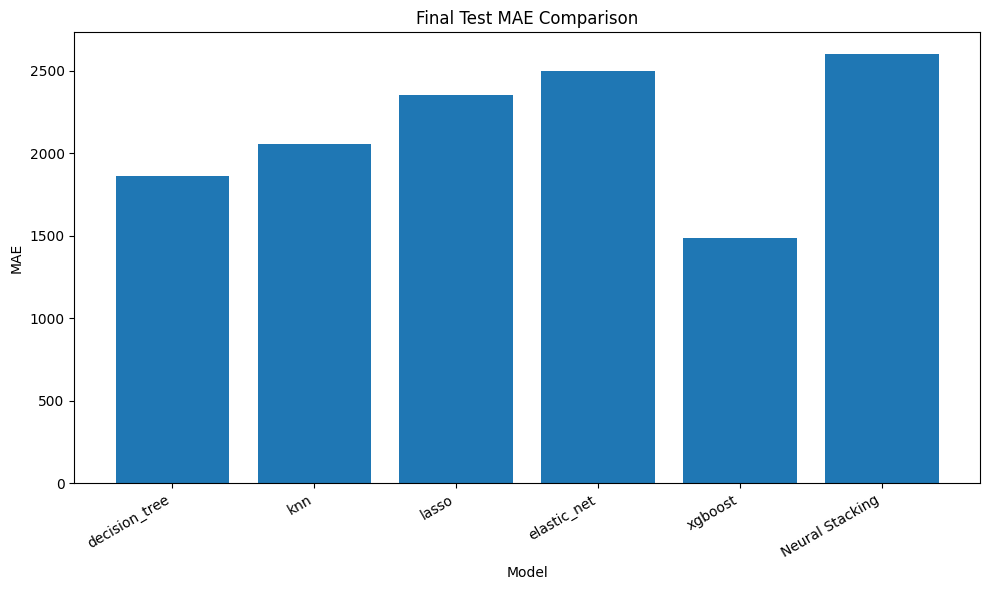

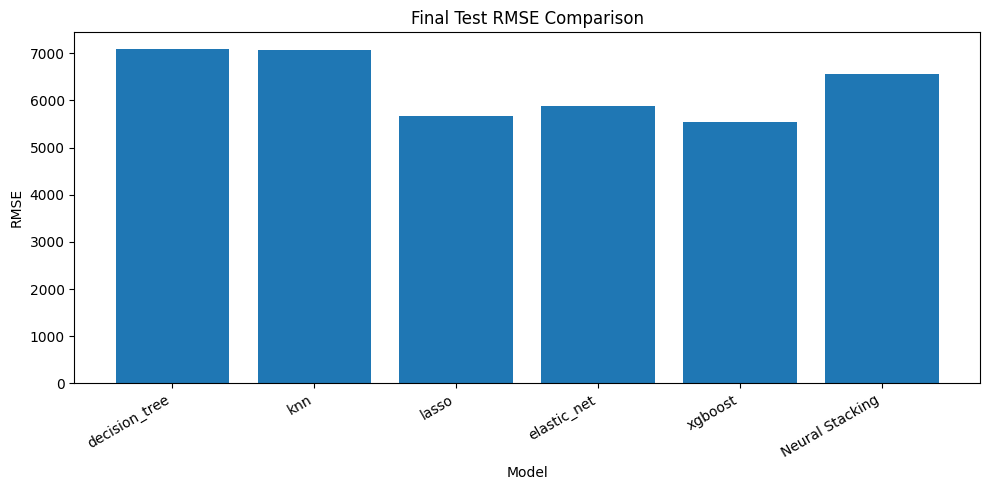

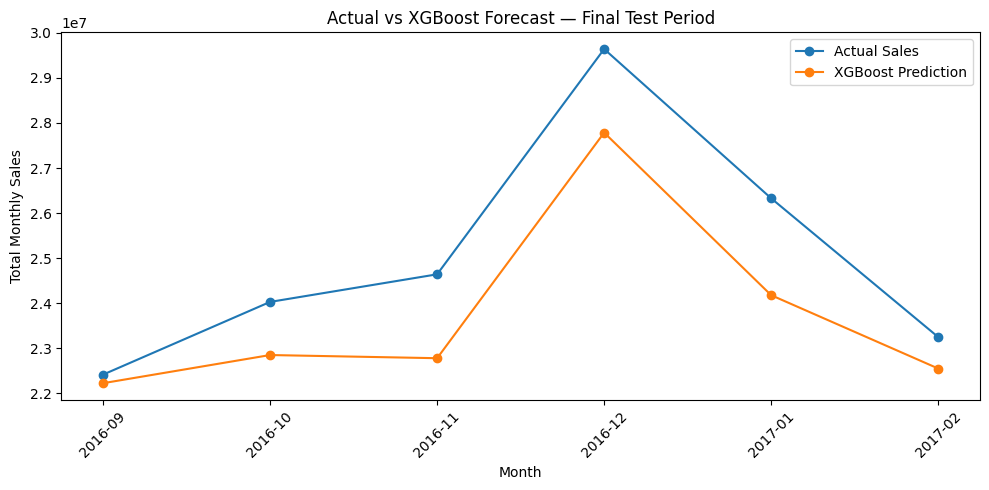

In [50]:
# ==========================================
# Step 35: Final Project Visualizations
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------
# 1. Model Comparison — MAE
# ------------------------------------------

plot_df = final_results_df.copy()

plt.figure(figsize=(10, 6))
plt.bar(plot_df["Model"], plot_df["MAE"])
plt.ylabel("MAE")
plt.xlabel("Model")
plt.title("Final Test MAE Comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("model_comparison_mae.png", dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------
# 2. Model Comparison — RMSE
# ------------------------------------------

plt.figure(figsize=(10, 5))
plt.bar(plot_df["Model"], plot_df["RMSE"])
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.title("Final Test RMSE Comparison")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("model_comparison_rmse.png", dpi=300, bbox_inches="tight")
plt.show()


# ------------------------------------------
# 3. Actual vs XGBoost Predictions
# ------------------------------------------

# Aggregate across all store-family series by month
test_plot = test_data[
    ["month", "sales"]
].copy()

test_plot["xgboost_pred"] = final_test_predictions["xgboost"]

monthly_actual = (
    test_plot
    .groupby("month")["sales"]
    .sum()
)

monthly_xgb = (
    test_plot
    .groupby("month")["xgboost_pred"]
    .sum()
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_actual.index.astype(str),
    monthly_actual.values,
    marker="o",
    label="Actual Sales"
)

plt.plot(
    monthly_xgb.index.astype(str),
    monthly_xgb.values,
    marker="o",
    label="XGBoost Prediction"
)

plt.xlabel("Month")
plt.ylabel("Total Monthly Sales")
plt.title("Actual vs XGBoost Forecast — Final Test Period")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.savefig(
    "actual_vs_xgboost_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()